# Hate Speech Detection using DistilBERT
### HASOC Dataset — Hindi → English Translated
**Author:** Your Name  
**Model:** distilbert-base-uncased (fine-tuned)  
**Baseline:** Logistic Regression + TF-IDF → 80% accuracy  
**Goal:** Beat baseline using transformer-based deep learning

## Cell 1 — Install Required Libraries
Run this only once. Restart kernel after installation.

In [1]:
# Install HuggingFace transformers and PyTorch
# Run once, then restart kernel
# !pip install transformers torch scikit-learn

## Cell 2 — Import All Libraries
**What each library does:**
- `transformers` → provides DistilBERT model and tokenizer (from HuggingFace)
- `torch` → PyTorch deep learning framework, handles tensors and training
- `torch.nn` → neural network modules (loss functions, layers)
- `torch.utils.data` → Dataset and DataLoader for batching
- `sklearn` → train/test split, metrics (accuracy, F1)
- `pandas, numpy` → data handling

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available (will say CPU for you — that is fine)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
# Expected output: Using device: cpu

Using device: cpu


## Cell 3 — Load Your Existing Dataset
We load the same CSV you already used in your LR model.
We use `translated_text` column — same as your LR pipeline.

In [3]:
# Load dataset — same file as your LR model
df = pd.read_csv('translated_hindi_dataset.csv')

# Drop rows where translated_text is missing (10 rows — same as your notebook)
df = df.dropna(subset=['translated_text'])

print(f"Total rows: {len(df)}")
print(f"Label distribution:\n{df['Label_binary'].value_counts()}")
df.head(3)

Total rows: 4655
Label distribution:
Label_binary
1    2465
0    2190
Name: count, dtype: int64


,text,Label_binary,translated_text
0,"बांग्लादेश की शानदार वापसी, भारत को 314 रन पर ...",0,"Great comeback by Bangladesh, restricted India..."
1,सब रंडी नाच देखने मे व्यस्त जैसे ही कोई #शांती...,1,All the whores are busy watching the dance. As...
2,तुम जैसे हरामियों के लिए बस जूतों की कमी है शु...,1,There is just shortage of shoes for bastards l...


## Cell 4 — Light Cleaning for BERT

**IMPORTANT — Why less cleaning than your LR model?**

In your LR model, you did heavy cleaning:
- Removed stopwords (like 'the', 'is')
- Lemmatized words ('running' → 'run')
- Removed punctuation

This was necessary because TF-IDF treats each word independently — stopwords add noise.

**BERT is different:**
- BERT already understands grammar and sentence structure
- Removing 'not', 'never' destroys meaning (e.g., 'not hate' becomes 'hate')
- BERT's tokenizer handles punctuation internally
- So we only do minimal cleaning: remove URLs and extra spaces

In [4]:
import re

def light_clean(text):
    """
    Minimal cleaning for BERT:
    - Remove URLs (http/https links)
    - Remove @mentions (Twitter handles)
    - Remove hashtag symbol but keep the word (#hate → hate)
    - Remove extra whitespace
    - Keep punctuation — BERT understands it!
    """
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)   # Remove URLs
    text = re.sub(r'@\w+', '', text)               # Remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)          # Remove # but keep word
    text = re.sub(r'[^a-zA-Z\s.,!?]', ' ', text)  # Remove non-English chars
    text = re.sub(r'\s+', ' ', text).strip()       # Remove extra spaces
    return text.lower()

df['bert_text'] = df['translated_text'].apply(light_clean)

# Preview
print("Original:", df['translated_text'].iloc[1])
print("\nCleaned: ", df['bert_text'].iloc[1])

Original: All the whores are busy watching the dance. As soon as something happens with a #peacemaker, all the #whores will start crying.

Cleaned:  all the whores are busy watching the dance. as soon as something happens with a peacemaker, all the whores will start crying.


In [5]:
pd.set_option('display.max_Colwidth',None)
df.head()

,text,Label_binary,translated_text,bert_text
0,"बांग्लादेश की शानदार वापसी, भारत को 314 रन पर रोका #INDvBAN #CWC19",0,"Great comeback by Bangladesh, restricted India to 314 runs #INDvBAN #CWC19","great comeback by bangladesh, restricted india to runs indvban cwc"
1,सब रंडी नाच देखने मे व्यस्त जैसे ही कोई #शांतीदूत के साथ कुछ होगा सब #रंडीरोना शुरू कर देंगे,1,"All the whores are busy watching the dance. As soon as something happens with a #peacemaker, all the #whores will start crying.","all the whores are busy watching the dance. as soon as something happens with a peacemaker, all the whores will start crying."
2,तुम जैसे हरामियों के लिए बस जूतों की कमी है शुक्र कर अभी तुम्हारी लिंचिंग हुई नहीं है हिंदुओं के जागने की देर है सच में होगी अभी तो तुम जैसे हरामी सुवर ड्रामा बनाएं हो सुवर कहीं का मौलाना। तुम जैसे हरामियों कुत्ते की मौत मारना चाहिए सुवर जैसी शक्ल रंडी की औलाद सुवर कहीं का ।।।।,1,"There is just shortage of shoes for bastards like you. Thank God you have not been lynched yet. It is too late for the Hindus to wake up. It will actually happen now. Bastards like you have created a pig drama, some Maulana of a pig. Bastards like you, the dog should be killed, the pig-like face, the son of a whore, the pig from somewhere.","there is just shortage of shoes for bastards like you. thank god you have not been lynched yet. it is too late for the hindus to wake up. it will actually happen now. bastards like you have created a pig drama, some maulana of a pig. bastards like you, the dog should be killed, the pig like face, the son of a whore, the pig from somewhere."
3,"बीजेपी MLA आकाश विजयवर्गीय जेल से रिहा, जमानत मिलने की खुशी में एक समर्थक ने इंदौर में हर्ष फायरिंग की #AkashVijayvargiya https://abpnews.abplive.in/india-news/celebratory-firing-outside-bjp-mla-akash-vijayvargiya-office-in-indore-1157241 …",0,"BJP MLA Akash Vijayvargiya released from jail, in celebration of getting bail, a supporter opened fire in Indore #AkashVijayvargiya https://abpnews.abplive.in/india-news/celebratory-firing-outside-bjp-mla-akash-vijayvargiya-office-in-indore-1157241…","bjp mla akash vijayvargiya released from jail, in celebration of getting bail, a supporter opened fire in indore akashvijayvargiya"
4,"चमकी बुखार: विधानसभा परिसर में आरजेडी का प्रदर्शन, तेजस्वी यादव नदारद #biharencephalitisdeaths https://abpnews.abplive.in/bihar-news/aes-deaths-rjd-protest-in-vidhan-sabha-campus-but-tejashwi-yadav-was-not-present-1158748 … (रिपोर्ट- @kumarprakash4u )",0,"Chamki fever: RJD's protest in the assembly campus, Tejashwi Yadav missing #biharencephalitisdeaths https://abpnews.abplive.in/bihar-news/aes-deaths-rjd-protest-in-vidhan-sabha-campus-but-tejashwi-yadav-was-not-present-1158748… (Report- @kumarprakash4u)","chamki fever rjd s protest in the assembly campus, tejashwi yadav missing biharencephalitisdeaths report"


## Cell 5 — Train/Test Split

We use the **same random_state=42 and test_size=0.2** as your LR model.
This ensures a **fair comparison** — both models see identical train/test data.

In [6]:
X = df['bert_text'].tolist()
y = df['Label_binary'].tolist()

# Same split as your LR model for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 3724
Testing  samples : 931


## Cell 6 — Load DistilBERT Tokenizer

**What is a Tokenizer?**
A tokenizer converts text into numbers that BERT can understand.

**What does it produce?**
- `input_ids` → Each word/subword is mapped to a unique number
- `attention_mask` → 1 for real tokens, 0 for padding (shorter sentences get padded)

**Example:**
```
'I hate you'  →  [101, 1045, 5223, 2017, 102]
                   ↑                        ↑
               [CLS] token           [SEP] token
```
[CLS] = start of sentence (its final vector is used for classification)
[SEP] = end of sentence

**MAX_LEN = 128:** Your average text length is 168 chars (~35 words), so 128 tokens covers most texts.

In [7]:
# Downloads ~250MB model from HuggingFace (first run only, then cached)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

MAX_LEN = 128  # Maximum tokens per sentence

# Demo: see what tokenization looks like
sample = "I hate you so much"
tokens = tokenizer(sample, return_tensors='pt')
print("Input IDs:", tokens['input_ids'])
print("Attention Mask:", tokens['attention_mask'])
print("Decoded back:", tokenizer.decode(tokens['input_ids'][0]))

Input IDs: tensor([[ 101, 1045, 5223, 2017, 2061, 2172,  102]])
Attention Mask: tensor([[1, 1, 1, 1, 1, 1, 1]])
Decoded back: [CLS] i hate you so much [SEP]


## Cell 7 — Create PyTorch Dataset

**What is a Dataset class?**
PyTorch requires data to be wrapped in a `Dataset` object.
It needs 3 methods:
- `__init__` → stores texts and labels
- `__len__` → returns total number of samples
- `__getitem__` → returns one tokenized sample by index

Think of it as a smart container that tokenizes text on-the-fly.

In [8]:
class HateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        # Returns total number of samples
        return len(self.texts)

    def __getitem__(self, idx):
        # Tokenize one text at a time
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',   # Pad shorter texts to MAX_LEN
            truncation=True,        # Cut longer texts at MAX_LEN
            return_tensors='pt'     # Return PyTorch tensors
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create train and test datasets
train_dataset = HateSpeechDataset(X_train, y_train, tokenizer, MAX_LEN)
test_dataset  = HateSpeechDataset(X_test,  y_test,  tokenizer, MAX_LEN)

# DataLoader batches the data
# batch_size=16 means 16 texts are processed at once
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 233
Test  batches : 30


## Cell 8 — Load DistilBERT Model

**Why DistilBERT instead of BERT?**
| | BERT | DistilBERT |
|---|---|---|
| Parameters | 110 million | 66 million |
| Speed | 1x | 1.6x faster |
| Accuracy | 100% | ~97% of BERT |
| CPU training | Very slow | Manageable |

**What is `num_labels=2`?**
Tells the model we have 2 classes: 0 (not hate) and 1 (hate speech).
This automatically adds a classification layer on top of DistilBERT.

In [9]:
# Load pretrained DistilBERT with a classification head on top
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2   # Binary: 0 = not hate, 1 = hate speech
)

# Move model to CPU (or GPU if available)
model = model.to(device)

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
# ~66 million parameters — this is what makes it powerful!

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters     : 66,955,010
Trainable parameters : 66,955,010


## Cell 9 — Set Up Optimizer

**What is an Optimizer?**
During training, the model makes predictions and calculates error (loss).
The optimizer uses that error to update the model's weights to reduce the error.

**AdamW** is the standard optimizer for transformers.

**Learning Rate = 2e-5 (0.00002)**
This is very small — we don't want to destroy BERT's pre-trained knowledge.
We are just *fine-tuning* (making small adjustments), not training from scratch.

Think of it like: BERT already knows English perfectly. We are just teaching it
the difference between hate speech and normal text using tiny weight adjustments.

In [10]:
from torch.optim import AdamW

# AdamW optimizer — standard for transformers
# lr=2e-5 is recommended for fine-tuning BERT/DistilBERT
optimizer = AdamW(model.parameters(), lr=2e-5)

# Loss function: CrossEntropyLoss for classification
# It measures how wrong the model's predictions are
criterion = nn.CrossEntropyLoss()

print("Optimizer and loss function ready!")

Optimizer and loss function ready!


## Cell 10 — Training Function

**What happens in one training epoch?**
1. Feed a batch of 16 texts into the model
2. Model predicts hate/not-hate probabilities
3. Calculate loss (how wrong the predictions are)
4. Backpropagation: calculate gradients (which direction to adjust weights)
5. Optimizer updates weights to reduce loss
6. Repeat for all batches

**model.train()** → puts model in training mode (enables dropout for regularization)
**optimizer.zero_grad()** → clears previous gradients before each batch
**loss.backward()** → computes gradients via backpropagation
**optimizer.step()** → updates weights

In [11]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()  # Set model to training mode
    total_loss    = 0
    all_preds     = []
    all_labels    = []

    for batch_num, batch in enumerate(loader):
        # Move batch data to device (CPU/GPU)
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()  # Clear old gradients

        # Forward pass: feed text into model, get predictions
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits  # Raw scores for each class [batch_size, 2]

        # Calculate loss: how wrong are our predictions?
        loss = criterion(logits, labels)

        # Backward pass: calculate gradients
        loss.backward()

        # Clip gradients to prevent exploding gradients problem
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update weights
        optimizer.step()

        total_loss += loss.item()

        # Get predicted class (0 or 1)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        # Progress update every 50 batches
        if (batch_num + 1) % 50 == 0:
            print(f"  Batch {batch_num+1}/{len(loader)} — Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy

## Cell 11 — Evaluation Function

**model.eval()** → disables dropout (we want deterministic predictions during testing)
**torch.no_grad()** → disables gradient calculation (saves memory, faster inference)
We don't update weights during evaluation — only during training.

In [12]:
def evaluate(model, loader, criterion, device):
    model.eval()  # Set model to evaluation mode
    total_loss = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():  # No gradient calculation needed
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits

            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy, all_preds, all_labels

## Cell 12 — Training Loop (3 Epochs)

**What is an Epoch?**
One epoch = model has seen ALL training data once.

We train for 3 epochs:
- Epoch 1: Model learns basic patterns
- Epoch 2: Model refines its understanding
- Epoch 3: Model fine-tunes further

**CPU Time Estimate for your 13th Gen i7:**
- Each epoch ≈ 10-15 minutes on CPU
- Total: ~35-45 minutes
- You can run this overnight or while doing something else

In [13]:
import time

EPOCHS = 3
best_test_accuracy = 0
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

print("=" * 60)
print("Starting DistilBERT Fine-tuning...")
print(f"Device: {device}")
print(f"Epochs: {EPOCHS}")
print(f"Training samples: {len(X_train)}")
print("=" * 60)

total_start = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    # Train for one epoch
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)

    # Evaluate on test set
    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)

    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    epoch_time = time.time() - epoch_start
    print(f"  Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"  Test  Loss: {test_loss:.4f}  | Test  Accuracy: {test_acc:.4f}")
    print(f"  Time: {epoch_time/60:.1f} minutes")

    # Save best model
    if test_acc > best_test_accuracy:
        best_test_accuracy = test_acc
        torch.save(model.state_dict(), 'best_distilbert_model.pt')
        print(f"  ✓ Best model saved! (accuracy: {best_test_accuracy:.4f})")

total_time = time.time() - total_start
print(f"\nTotal training time: {total_time/60:.1f} minutes")
print(f"Best test accuracy : {best_test_accuracy:.4f}")

Starting DistilBERT Fine-tuning...
Device: cpu
Epochs: 3
Training samples: 3724

Epoch 1/3
----------------------------------------
  Batch 50/233 — Loss: 0.5643
  Batch 100/233 — Loss: 0.2992
  Batch 150/233 — Loss: 0.3577
  Batch 200/233 — Loss: 0.1803
  Train Loss: 0.4840 | Train Accuracy: 0.7586
  Test  Loss: 0.3782  | Test  Accuracy: 0.8260
  Time: 53.6 minutes
  ✓ Best model saved! (accuracy: 0.8260)

Epoch 2/3
----------------------------------------
  Batch 50/233 — Loss: 0.4182
  Batch 100/233 — Loss: 0.2754
  Batch 150/233 — Loss: 0.2061
  Batch 200/233 — Loss: 0.3601
  Train Loss: 0.3253 | Train Accuracy: 0.8620
  Test  Loss: 0.3879  | Test  Accuracy: 0.8335
  Time: 47.5 minutes
  ✓ Best model saved! (accuracy: 0.8335)

Epoch 3/3
----------------------------------------
  Batch 50/233 — Loss: 0.1509
  Batch 100/233 — Loss: 0.1305
  Batch 150/233 — Loss: 0.0941
  Batch 200/233 — Loss: 0.0934
  Train Loss: 0.2186 | Train Accuracy: 0.9202
  Test  Loss: 0.5421  | Test  Accuracy:

## Cell 13 — Final Evaluation and Classification Report
This is the detailed results you need for your report and professor.

In [14]:
# Load best saved model
model.load_state_dict(torch.load('best_distilbert_model.pt', map_location=device))

# Get final predictions
_, final_acc, final_preds, final_labels = evaluate(model, test_loader, criterion, device)

print("=" * 60)
print("FINAL RESULTS — DistilBERT")
print("=" * 60)
print(f"\nTest Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")
print("\nDetailed Classification Report:")
print(classification_report(
    final_labels, final_preds,
    target_names=['Not Hate (0)', 'Hate Speech (1)']
))

FINAL RESULTS — DistilBERT

Test Accuracy: 0.8335 (83.35%)

Detailed Classification Report:
                 precision    recall  f1-score   support

   Not Hate (0)       0.81      0.84      0.82       437
Hate Speech (1)       0.85      0.83      0.84       494

       accuracy                           0.83       931
      macro avg       0.83      0.83      0.83       931
   weighted avg       0.83      0.83      0.83       931



## Cell 14 — LR vs BERT Comparison Table
This is the comparison you need for your report.

In [15]:
# Results from your LR model (from your existing notebook)
lr_results = {
    'Model'          : 'Logistic Regression + TF-IDF',
    'Accuracy'       : 0.80,
    'Precision (0)'  : 0.78,
    'Recall (0)'     : 0.79,
    'F1 (0)'         : 0.79,
    'Precision (1)'  : 0.81,
    'Recall (1)'     : 0.81,
    'F1 (1)'         : 0.81,
    'Macro F1'       : 0.80
}

# Update these with your actual BERT results after training
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, _ = precision_recall_fscore_support(final_labels, final_preds)
macro_f1 = f1.mean()

bert_results = {
    'Model'          : 'DistilBERT (Fine-tuned)',
    'Accuracy'       : round(final_acc, 4),
    'Precision (0)'  : round(precision[0], 4),
    'Recall (0)'     : round(recall[0], 4),
    'F1 (0)'         : round(f1[0], 4),
    'Precision (1)'  : round(precision[1], 4),
    'Recall (1)'     : round(recall[1], 4),
    'F1 (1)'         : round(f1[1], 4),
    'Macro F1'       : round(macro_f1, 4)
}

comparison_df = pd.DataFrame([lr_results, bert_results])
comparison_df = comparison_df.set_index('Model')

print("\nMODEL COMPARISON TABLE")
print("=" * 80)
print(comparison_df.to_string())

improvement = (bert_results['Accuracy'] - lr_results['Accuracy']) * 100
print(f"\nAccuracy improvement: +{improvement:.2f}% over Logistic Regression")


MODEL COMPARISON TABLE
                              Accuracy  Precision (0)  Recall (0)  F1 (0)  Precision (1)  Recall (1)  F1 (1)  Macro F1
Model                                                                                                                 
Logistic Regression + TF-IDF    0.8000         0.7800      0.7900  0.7900         0.8100       0.810  0.8100    0.8000
DistilBERT (Fine-tuned)         0.8335         0.8147      0.8352  0.8249         0.8509       0.832  0.8414    0.8331

Accuracy improvement: +3.35% over Logistic Regression


## Cell 15 — Predict on New Hindi Text (Input Pipeline)
This replicates your existing input pipeline — takes Hindi text, translates, predicts.

In [16]:
from deep_translator import GoogleTranslator

translator = GoogleTranslator(source='auto', target='en')

def predict_hate_speech(text, model, tokenizer, device):
    """
    Full prediction pipeline:
    1. Translate Hindi → English (if needed)
    2. Clean text
    3. Tokenize
    4. Predict with DistilBERT
    5. Return label + confidence
    """
    # Step 1: Translate
    english_text = translator.translate(text)

    # Step 2: Clean
    cleaned = light_clean(english_text)

    # Step 3: Tokenize
    encoding = tokenizer(
        cleaned,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    # Step 4: Predict
    model.eval()
    with torch.no_grad():
        outputs = model(
            input_ids=encoding['input_ids'].to(device),
            attention_mask=encoding['attention_mask'].to(device)
        )

    # Step 5: Get probabilities
    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    pred_class = int(np.argmax(probs))

    label = 'HATE SPEECH' if pred_class == 1 else 'NOT HATE'
    confidence = probs[pred_class] * 100

    return {
        'input_text'    : text,
        'translated'    : english_text,
        'prediction'    : label,
        'confidence'    : f"{confidence:.1f}%",
        'prob_not_hate' : f"{probs[0]*100:.1f}%",
        'prob_hate'     : f"{probs[1]*100:.1f}%"
    }


# Test with your same test statements from LR notebook
test_statements = [
    # "कुत्ते की तरह भौंकना बंद कर, तेरी कोई औकात नहीं है।",
    # "आज मौसम बहुत अच्छा है, चलो कहीं घूमने चलते हैं।",
    # "तू एक नंबर का झूठा और नीच इंसान है।",
    # "मैं किसी से नफरत नहीं करता, सब मेरे दोस्त हैं।",
    "तुम मोटे हो, अपना मुंह बंद रखो।"
]

print("BERT Predictions:")
print("=" * 70)
for stmt in test_statements:
    result = predict_hate_speech(stmt, model, tokenizer, device)
    print(f"Text       : {result['input_text'][:50]}...")
    print(f"Prediction : {result['prediction']} (Confidence: {result['confidence']})")
    print(f"Not Hate   : {result['prob_not_hate']}  |  Hate: {result['prob_hate']}")
    print("-" * 70)

BERT Predictions:
Text       : तुम मोटे हो, अपना मुंह बंद रखो।...
Prediction : HATE SPEECH (Confidence: 95.0%)
Not Hate   : 5.0%  |  Hate: 95.0%
----------------------------------------------------------------------


## Cell 16 — Training Curve Plot
Visual showing how model improved over epochs — good to include in report.

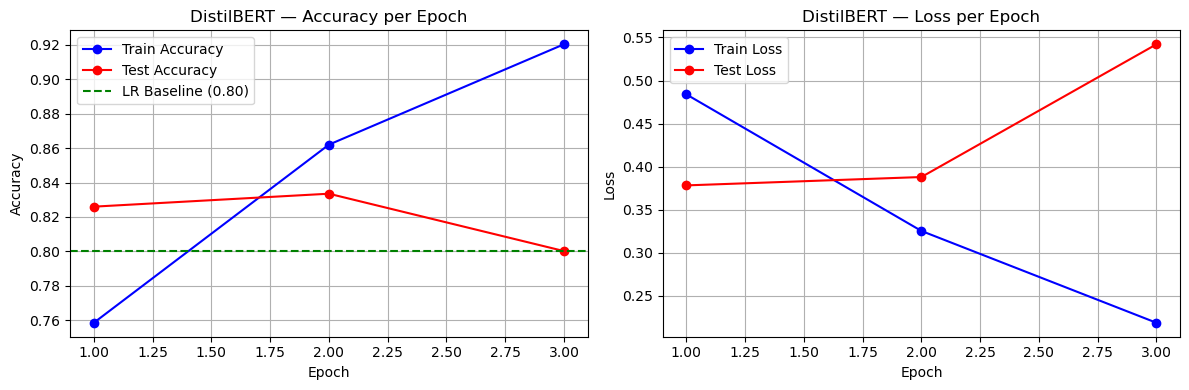

Plot saved as training_curves.png


In [17]:
# import matplotlib.pyplot as plt

# epochs_range = range(1, EPOCHS + 1)

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# # Accuracy plot
# axes[0].plot(epochs_range, history['train_acc'], 'b-o', label='Train Accuracy')
# axes[0].plot(epochs_range, history['test_acc'],  'r-o', label='Test Accuracy')
# axes[0].axhline(y=0.80, color='g', linestyle='--', label='LR Baseline (0.80)')
# axes[0].set_xlabel('Epoch')
# axes[0].set_ylabel('Accuracy')
# axes[0].set_title('DistilBERT — Accuracy per Epoch')
# axes[0].legend()
# axes[0].grid(True)

# # Loss plot
# axes[1].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
# axes[1].plot(epochs_range, history['test_loss'],  'r-o', label='Test Loss')
# axes[1].set_xlabel('Epoch')
# axes[1].set_ylabel('Loss')
# axes[1].set_title('DistilBERT — Loss per Epoch')
# axes[1].legend()
# axes[1].grid(True)

# plt.tight_layout()
# plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("Plot saved as training_curves.png")

---
## Summary: What to Tell Your Professor

### 1. Why DistilBERT over BERT?
> DistilBERT retains 97% of BERT's performance while being 40% smaller and 60% faster. Since training was done on CPU without GPU access, DistilBERT was the practical choice for this experiment.

### 2. Why less cleaning for BERT?
> BERT is a contextual model trained on natural language. It already understands stopwords, grammar, and punctuation as part of sentence context. Removing them (as done for TF-IDF) would destroy contextual signals. For example, 'not hate' would become 'hate' — the opposite meaning.

### 3. What is fine-tuning?
> DistilBERT was pre-trained on 3+ billion words (Wikipedia + BooksCorpus) and already understands English. Fine-tuning means we added a classification layer on top and trained it for 3 more epochs on our 4,655-sample HASOC dataset. The pre-trained weights were adjusted slightly (learning rate=2e-5) to specialize for hate speech detection.

### 4. How does BERT classify text?
> BERT uses a special [CLS] token at the start of every sentence. After passing through 6 transformer layers (DistilBERT), the [CLS] token's vector captures the meaning of the entire sentence. This 768-dimensional vector is passed to a linear classification layer that outputs hate/not-hate probabilities.

### 5. Why is BERT better than LR+TF-IDF?
> TF-IDF treats each word independently (bag-of-words). It cannot understand:
> - Context: 'not bad' vs 'bad'
> - Word order: 'dog bites man' vs 'man bites dog'
> - Sarcasm or implied hate
>
> BERT's self-attention mechanism allows every word to attend to every other word, capturing these complex relationships.

In [18]:
import os

SAVE_PATH = './hate_speech_model'  # folder name — you can change this
os.makedirs(SAVE_PATH, exist_ok=True)

# Save model weights + config together
model.save_pretrained(SAVE_PATH)

# Save tokenizer too (so no re-download needed)
tokenizer.save_pretrained(SAVE_PATH)

print(f'Model saved to: {SAVE_PATH}')
print(f'Files saved:')
for f in os.listdir(SAVE_PATH):
    size = os.path.getsize(f'{SAVE_PATH}/{f}') / (1024*1024)
    print(f'  {f}  ({size:.1f} MB)')

# Expected output:
# config.json          (0.0 MB)  — model architecture info
# tokenizer.json       (0.7 MB)  — tokenizer vocabulary
# tokenizer_config.json(0.0 MB)  — tokenizer settings
# vocab.txt            (0.2 MB)  — word vocabulary
# model.safetensors    (255 MB)  — the actual trained weights (biggest file)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./hate_speech_model
Files saved:
  config.json  (0.0 MB)
  model.safetensors  (255.4 MB)
  tokenizer.json  (0.7 MB)
  tokenizer_config.json  (0.0 MB)


In [2]:
# ============================================================
# NEXT SESSION — Run only these imports + this cell
# You do NOT need to re-run training cells
# ============================================================

import torch
import numpy as np
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

SAVE_PATH = './hate_speech_model'  # same folder name as above

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load tokenizer from saved folder
tokenizer = DistilBertTokenizer.from_pretrained(SAVE_PATH)

# Load model from saved folder
model = DistilBertForSequenceClassification.from_pretrained(SAVE_PATH)
model = model.to(device)
model.eval()  # set to evaluation mode — important!

print('Model loaded successfully!')
print(f'Device: {device}')
# Ready to use — no retraining needed

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded successfully!
Device: cpu


In [4]:
import re
from deep_translator import GoogleTranslator

translator = GoogleTranslator(source='auto', target='en')

def light_clean(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-zA-Z\s.,!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

def predict(text):
    """
    Full pipeline:
    Hindi text → translate → clean → tokenize → predict
    """
    # Step 1: Translate
    english = translator.translate(text)

    # Step 2: Clean
    cleaned = light_clean(english)

    # Step 3: Tokenize
    inputs = tokenizer(
        cleaned,
        return_tensors='pt',
        max_length=128,
        truncation=True,
        padding='max_length'
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Step 4: Predict
    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    pred  = int(np.argmax(probs))

    print(f'Input     : {text}')
    print(f'Translated: {english}')
    print(f'Prediction: {"🚨 HATE SPEECH" if pred == 1 else "✅ NOT HATE"}')
    print(f'Confidence: {probs[pred]*100:.1f}%')
    print('-' * 50)

# Test with same sentences from your original notebook
predict('आज मौसम बहुत अच्छा है')                      # Should be NOT HATE
predict('कुत्ते की तरह भौंकना बंद कर')                # Should be HATE
predict('मैं सबसे प्यार करता हूं')                    # Should be NOT HATE
predict('तुम एक बड़े और मोटे सूअर हो')                    # Should be NOT HATE

Input     : आज मौसम बहुत अच्छा है
Translated: the weather is very nice today
Prediction: ✅ NOT HATE
Confidence: 96.0%
--------------------------------------------------
Input     : कुत्ते की तरह भौंकना बंद कर
Translated: stop barking like a dog
Prediction: 🚨 HATE SPEECH
Confidence: 95.2%
--------------------------------------------------
Input     : मैं सबसे प्यार करता हूं
Translated: i love everyone
Prediction: ✅ NOT HATE
Confidence: 93.9%
--------------------------------------------------
Input     : तुम एक बड़े और मोटे सूअर हो
Translated: you are a big and fat pig
Prediction: 🚨 HATE SPEECH
Confidence: 98.4%
--------------------------------------------------


In [6]:
predict('हम तुमसे प्यार करते हैं')                    # Should be NOT HATE

Input     : हम तुमसे प्यार करते हैं
Translated: we love you
Prediction: ✅ NOT HATE
Confidence: 93.6%
--------------------------------------------------
